# So sanh model du bao gia ca phe Robusta noi dia (theo ngay)

**Muc tieu:** du bao muc gia `Gia_target` (TB Dak Lak + Lam Dong, VND/kg) theo ngay, chi dung **ML co dien** (khong deep learning).

**Du lieu:** `gia_cafe_master.csv` — 1.566 ngay lam viec (2020-2025), 18 feature (tu hoi quy gia + lich + London/ty gia + dau diesel + xuat khau + thoi tiet/ONI).

**Pipeline:**
1. Nap & chuan bi du lieu (xu ly NaN, chong ro ri)
2. Chon khung target: `level` (muc gia) hoac `delta` (thay doi) — delta giup mo hinh cay ngoai suy duoc tren dinh gia ky luc
3. Metric: MAE, RMSE, sMAPE, MASE, Directional Accuracy
4. Walk-forward CV (cua so mo rong)
5. Bo model: Naive, ARIMAX, Ridge/Lasso/ElasticNet, RandomForest, XGBoost, LightGBM, SVR, kNN
6. Bang ket qua + truc quan + feature importance + kiem dinh Diebold-Mariano

> Tat ca model deu duoc danh gia tren **muc gia** de so sanh cong bang.

In [92]:
# Neu chay tren Colab/may chua co thu vien, bo comment dong duoi:
# !pip install scikit-learn scipy statsmodels xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

HAS_XGB = True
try:
    from xgboost import XGBRegressor
except Exception:
    HAS_XGB = False

HAS_LGB = True
try:
    from lightgbm import LGBMRegressor
except Exception:
    HAS_LGB = False

HAS_SM = True
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
except Exception:
    HAS_SM = False

plt.rcParams['figure.figsize'] = (12, 5)
print('xgboost:', HAS_XGB, '| lightgbm:', HAS_LGB, '| statsmodels:', HAS_SM)

xgboost: True | lightgbm: True | statsmodels: True


## 1. Nap du lieu

In [93]:
CSV_PATH = 'data/processed/gia_cafe_master_full.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['Ngay']).sort_values('Ngay').reset_index(drop=True)
df = df.set_index('Ngay')
print('Shape:', df.shape)
print('Khoang thoi gian:', df.index.min().date(), '->', df.index.max().date())

# --- KIEM TRA CHONG NHAM FILE CU (bi ro ri) ---
n_weekend = int((df.index.dayofweek >= 5).sum())
if n_weekend > 0:
    print(f"\n[CANH BAO] Co {n_weekend} dong cuoi tuan (T7/CN) -> day la MASTER CU bi ro ri!")
    print("           Hay chay lai: gia_taynguyen.py + 41_build_master_full.py de ghi de file.")
    print("           File dung phai co ~1566 dong, 0 dong cuoi tuan.")
else:
    print(f"\n[OK] Khong co ngay cuoi tuan. So dong: {len(df)} (ky vong ~1566).")
df.head()


Shape: (1566, 26)
Khoang thoi gian: 2020-01-01 -> 2025-12-31

[OK] Khong co ngay cuoi tuan. So dong: 1566 (ky vong ~1566).


,Gia_target,outlier_flag,target_lag1,target_lag2,target_lag3,target_ret_lag1,MA5,MA10,std5,dayofweek,...,rain_90d,oni,waterbal_90d,Luong_lag1m,dongia_lag1m,dongia_ret_lag1m,area_tn,prod_tn,yield_tn,tonkho_tan
Ngay,,,,,,,,,,,,,,,,,,,,,
2020-01-01,32319.5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,203.479996,0.58,-142.271622,87.5,1800.800000,-0.014087,618.0,1511494.4,2.445784,33360.0
2020-01-02,32319.5,0,32319.5,NaN,NaN,NaN,NaN,NaN,NaN,3,...,188.599996,0.58,-157.761064,87.5,1800.800000,-0.014087,618.0,1511494.4,2.445784,33360.0
2020-01-03,32269.5,0,32319.5,32319.5,NaN,0.000000,NaN,NaN,NaN,4,...,180.959996,0.58,-166.691354,87.5,1800.800000,-0.014087,618.0,1511494.4,2.445784,33360.0
2020-01-06,32460.5,0,32269.5,32319.5,32319.5,-0.001547,32302.833333,NaN,28.867513,0,...,176.779996,0.58,-170.171394,112.9,1738.352524,-0.034678,618.0,1511494.4,2.445784,33360.0
2020-01-07,32127.0,0,32460.5,32269.5,32319.5,0.005919,32342.250000,NaN,82.281529,1,...,175.179996,0.58,-171.686609,112.9,1738.352524,-0.034678,618.0,1511494.4,2.445784,33360.0


## 2. Chuan bi feature / target

Bo cac cot de gay **ro ri** (gia thanh phan Dak Lak/Lam Dong = chinh la target) va xu ly NaN (ngay khuyet gia + warmup cua lag/rolling).

In [94]:
TARGET = 'Gia_target'

# Bo 24 feature day du khop mo hinh huong 66,1% trong bao cao
AR = ['target_lag1','target_lag2','target_lag3','target_ret_lag1',
      'MA5','MA10','std5','dayofweek','month']
EXO = ['london_vnd_kg_lag1','usdvnd_lag1','diesel','diesel_chg_1m','diesel_chg_3m',
       'Luong_lag1m','rain_90d','oni','waterbal_90d']
SUPPLY = ['area_tn','prod_tn','yield_tn','tonkho_tan','dongia_lag1m','dongia_ret_lag1m']
WANT = AR + EXO + SUPPLY

# Chi giu cot thuc su co trong file; canh bao cot thieu
FEATURES = [c for c in WANT if c in df.columns]
missing = [c for c in WANT if c not in df.columns]
if missing:
    print('[CANH BAO] Thieu', len(missing), 'feature trong file:', missing)
    print('           -> Hay chay lai 41_build_master_full.py de sinh du 24 feature.')
print('Dung', len(FEATURES), 'feature:', FEATURES)

data = df[[TARGET] + FEATURES].copy()

# prev_price (gia ngay truoc) dung cho Naive va delta mode; KHONG nam trong FEATURES
prev_price = data[TARGET].shift(1).rename('prev_price')
data['prev_price'] = prev_price

before = len(data)
data = data.dropna(subset=[TARGET] + FEATURES + ['prev_price'])
print('Bo', before - len(data), 'dong NaN (warm-up + dut bao gia) ->', len(data), 'dong dung duoc')

X = data[FEATURES].copy()
prev_series = data['prev_price'].copy()
y_level = data[TARGET].copy()
print('X:', X.shape, '| y:', y_level.shape)


Dung 24 feature: ['target_lag1', 'target_lag2', 'target_lag3', 'target_ret_lag1', 'MA5', 'MA10', 'std5', 'dayofweek', 'month', 'london_vnd_kg_lag1', 'usdvnd_lag1', 'diesel', 'diesel_chg_1m', 'diesel_chg_3m', 'Luong_lag1m', 'rain_90d', 'oni', 'waterbal_90d', 'area_tn', 'prod_tn', 'yield_tn', 'tonkho_tan', 'dongia_lag1m', 'dongia_ret_lag1m']
Bo 50 dong NaN (warm-up + dut bao gia) -> 1516 dong dung duoc
X: (1516, 24) | y: (1516,)


## 3. Khung target: `level` vs `delta`

Gia tang ky luc (32k -> 97k VND/kg). **Mo hinh cay khong ngoai suy duoc** (khong du bao cao hon max da thay khi train).

- `level`: du bao truc tiep muc gia.
- `delta`: du bao `gia - target_lag1` roi cong lai `target_lag1` -> bo qua tran, hop voi chuoi co xu huong manh.

Doi `TARGET_MODE` de thu nghiem.

In [95]:
# === CHON CHAN TROI DU BAO ===
# HORIZON = so ngay LAM VIEC du bao toi:
#   1  = ngay mai        5  = 1 tuan        10 = 2 tuan
#   21 = 1 thang         63 = 1 quy
# Doi gia tri nay roi chay lai tu cell nay tro xuong de co ket qua tung chan troi.
HORIZON = 63
TARGET_MODE = 'delta'   # 'delta' (du bao thay doi gia) hoac 'level'

_HN = {1:'1 ngay (ngay mai)',5:'1 tuan',10:'2 tuan',21:'1 thang',63:'1 quy'}
HORIZON_NAME = _HN.get(HORIZON, f'{HORIZON} ngay lam viec')

price  = y_level.copy()            # gia(t) - da biet tai thoi diem t
future = price.shift(-HORIZON)     # gia(t+h) - dai luong CAN du bao
anchor = price.copy()              # moc hien tai = gia(t)

print(f'HORIZON = {HORIZON} ngay lam viec ({HORIZON_NAME}) | TARGET_MODE = {TARGET_MODE}')
print(f'Du bao gia(t+{HORIZON}) tu thong tin biet den ngay t (KHONG phai ngay mai).')


HORIZON = 63 ngay lam viec (1 quy) | TARGET_MODE = delta
Du bao gia(t+63) tu thong tin biet den ngay t (KHONG phai ngay mai).


## 4. Metric danh gia

In [96]:
def mae(a, p):  return float(np.mean(np.abs(a - p)))
def rmse(a, p): return float(np.sqrt(np.mean((a - p) ** 2)))

def smape(a, p):
    denom = (np.abs(a) + np.abs(p)) / 2.0
    return float(np.mean(np.abs(a - p) / np.where(denom == 0, np.nan, denom)) * 100)

def mase(a, p, y_train):
    # SUA: mau so = MAE naive tren PHAN TRAIN BAN DAU (khong gom test).
    # Ban cu dung toan chuoi (ca test) -> lech chuan MASE.
    d = np.mean(np.abs(np.diff(y_train)))
    return float(mae(a, p) / d)

def directional_accuracy(a, p, prev):
    # ti le du bao dung huong tang/giam so voi ngay truoc
    return float(np.mean(np.sign(a - prev) == np.sign(p - prev)) * 100)

## 5. Walk-forward CV (cua so mo rong)

Re-fit moi `STEP` ngay (mac dinh 21 ~ 1 thang) tren toan bo du lieu qua khu, du bao khoi tiep theo. Khong bao gio dung du lieu tuong lai.

In [97]:
def walk_forward(make_model, X, future, anchor, initial=0.6, step=5, horizon=5, mode='delta'):
    # Walk-forward expanding window. Tai moi diem quyet dinh d:
    #   - du bao gia(t+h) = gia(d+horizon)
    #   - TRAIN chi gom cac cap (t, t+h) da hoan thanh: t+h <= d  <=>  t <= d-horizon
    #     -> nhan huan luyen khong nhin tuong lai.
    n = len(X)
    start = int(n * initial)
    recs = []
    for d in range(start, n - horizon, step):
        tr = d - horizon + 1                 # so dong train hop le (t = 0..d-horizon)
        if tr <= 20:
            continue
        Xtr = X.iloc[:tr]
        ytr = (future - anchor).iloc[:tr] if mode == 'delta' else future.iloc[:tr]
        m = make_model(); m.fit(Xtr, ytr)
        raw = float(m.predict(X.iloc[[d]])[0])
        pred = float(anchor.iloc[d]) + raw if mode == 'delta' else raw
        recs.append((X.index[d], float(future.iloc[d]), float(anchor.iloc[d]), pred))
    return pd.DataFrame(recs, columns=['Ngay','y_true','anchor','pred']).set_index('Ngay')


## 6. Dinh nghia model

In [98]:
def make_models():
    m = {}
    m['Ridge']      = lambda: Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))])
    m['Lasso']      = lambda: Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.001, max_iter=10000))])
    m['ElasticNet'] = lambda: Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))])
    m['RandomForest'] = lambda: RandomForestRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=42)
    if HAS_XGB:
        m['XGBoost'] = lambda: XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=4,
                                            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    if HAS_LGB:
        m['LightGBM'] = lambda: LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
    m['SVR'] = lambda: Pipeline([('sc', StandardScaler()), ('m', SVR(C=10.0, epsilon=0.1, kernel='rbf'))])
    m['kNN'] = lambda: Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=10))])
    return m

MODELS = make_models()
print('Models:', list(MODELS.keys()))

Models: ['Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'XGBoost', 'LightGBM', 'SVR', 'kNN']


## 7. Baseline: Naive + ARIMAX

In [99]:
INITIAL, STEP = 0.6, 5      # STEP = nhip lay diem test (giam chong lap), KHONG phai chan troi
results_blocks = {}
n = len(X); start = int(n * INITIAL)

# --- Naive (random walk): du bao gia(t+h) = gia(t) hien tai (khong doi) ---
naive_rows = []
for d in range(start, n - HORIZON, STEP):
    naive_rows.append((X.index[d], float(future.iloc[d]), float(anchor.iloc[d]), float(anchor.iloc[d])))
naive_df = pd.DataFrame(naive_rows, columns=['Ngay','y_true','anchor','pred']).set_index('Ngay')
results_blocks['Naive'] = naive_df

EVAL    = naive_df.index                 # truc thoi gian danh gia chung
y_true  = naive_df['y_true'].values      # = gia(t+h) thuc te
anchor_eval = naive_df['anchor'].values  # = gia(t)
print(f'So diem test (chan troi {HORIZON_NAME}): {len(EVAL)}')

# --- ARIMAX(1,1,1): fit den ngay t, du bao h buoc, lay buoc thu h ---
# Exog giu co dinh = gia tri ngay t (tranh dung exog tuong lai -> khong look-ahead).
if HAS_SM:
    exog_cols = [c for c in EXO if c in FEATURES]
    arx_rows = []
    for d in range(start, n - HORIZON, STEP):
        tr = d + 1
        try:
            r = SARIMAX(price.iloc[:tr], exog=X[exog_cols].iloc[:tr], order=(1,1,1),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            exog_future = np.tile(X[exog_cols].iloc[[d]].values, (HORIZON, 1))
            fc = np.asarray(r.forecast(steps=HORIZON, exog=exog_future))
            pred = float(fc[-1])
        except Exception:
            pred = float(anchor.iloc[d])
        arx_rows.append((X.index[d], float(future.iloc[d]), float(anchor.iloc[d]), pred))
    results_blocks['ARIMAX(1,1,1)'] = pd.DataFrame(
        arx_rows, columns=['Ngay','y_true','anchor','pred']).set_index('Ngay')
else:
    print('Bo qua ARIMAX (chua co statsmodels)')


So diem test (chan troi 1 quy): 109


c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\env

## 8. Chay tat ca model ML

In [100]:
for name, factory in MODELS.items():
    results_blocks[name] = walk_forward(
        factory, X, future, anchor,
        initial=INITIAL, step=STEP, horizon=HORIZON, mode=TARGET_MODE)
print('Da chay:', list(results_blocks.keys()))


c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.867e+09, tolerance: 1.755e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.954e+09, tolerance: 1.841e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

Da chay: ['Naive', 'ARIMAX(1,1,1)', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'XGBoost', 'LightGBM', 'SVR', 'kNN']


## 9. Bang ket qua

In [101]:
# MASE: mau so = MAE naive 1-buoc tren PHAN TRAIN BAN DAU (khong gom test)
y_train_mase = price.values[:int(len(price) * INITIAL)]
rows = []
for name, blk in results_blocks.items():
    b = blk.reindex(EVAL)
    p = b['pred'].values.astype(float)
    a = b['y_true'].values.astype(float)
    anc = b['anchor'].values.astype(float)
    msk = np.isfinite(p) & np.isfinite(a)
    rows.append({
        'Model': name,
        'MAE':   mae(a[msk], p[msk]),
        'RMSE':  rmse(a[msk], p[msk]),
        'sMAPE(%)': smape(a[msk], p[msk]),
        'MASE':  mase(a[msk], p[msk], y_train_mase),
        'DA(%)': directional_accuracy(a[msk], p[msk], anc[msk]),
    })
res = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
res.to_csv(f'model_comparison_h{HORIZON}_{TARGET_MODE}.csv', index=False)
print(f'=== Chan troi {HORIZON_NAME} (h={HORIZON}, n={len(EVAL)} diem test) ===')
res


=== Chan troi 1 quy (h=63, n=109 diem test) ===


,Model,MAE,RMSE,sMAPE(%),MASE,DA(%)
0,SVR,15796.034975,19869.648126,15.788903,52.688982,58.715596
1,Naive,15945.999083,20063.276613,16.074592,53.189200,0.000000
2,RandomForest,15793.092976,20369.114414,15.483959,52.679169,58.715596
3,XGBoost,16814.889927,21223.712896,16.305619,56.087457,54.128440
4,LightGBM,17505.338099,21973.855078,16.998721,58.390504,52.293578
5,kNN,20828.530275,25058.643154,20.574693,69.475287,37.614679
6,Ridge,21368.777296,25676.116623,19.757139,71.277325,48.623853
7,ElasticNet,21519.508894,25926.011265,19.823398,71.780103,49.541284
8,Lasso,21531.625601,26005.120244,19.766047,71.820519,50.458716
9,"ARIMAX(1,1,1)",19273.824715,29385.288769,17.782435,64.289438,46.788991


## 10. Truc quan du bao (model tot nhat)

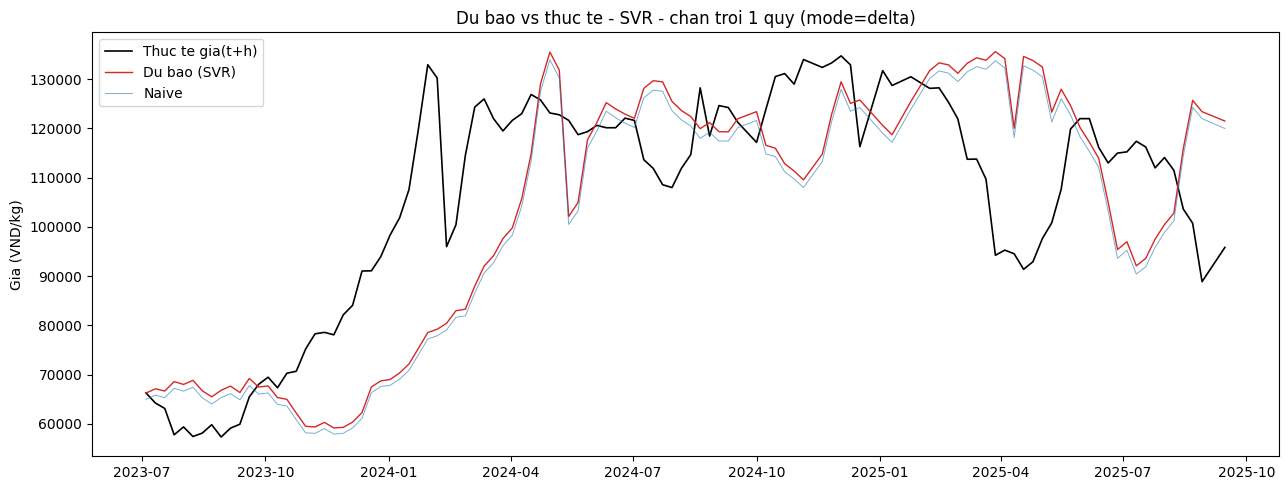

In [102]:
best = res.iloc[0]['Model']
bb = results_blocks[best].reindex(EVAL)
nn = results_blocks['Naive'].reindex(EVAL)
plt.figure(figsize=(13,5))
plt.plot(EVAL, y_true,        label='Thuc te gia(t+h)', color='black', lw=1.2)
plt.plot(EVAL, bb['pred'],    label='Du bao (' + best + ')', color='tab:red', lw=1)
plt.plot(EVAL, nn['pred'],    label='Naive', color='tab:blue', lw=0.7, alpha=0.6)
plt.title(f'Du bao vs thuc te - {best} - chan troi {HORIZON_NAME} (mode={TARGET_MODE})')
plt.ylabel('Gia (VND/kg)'); plt.legend(); plt.tight_layout()
plt.savefig(f'forecast_best_h{HORIZON}_{TARGET_MODE}.png', dpi=120)
plt.show()


## 11. Feature importance

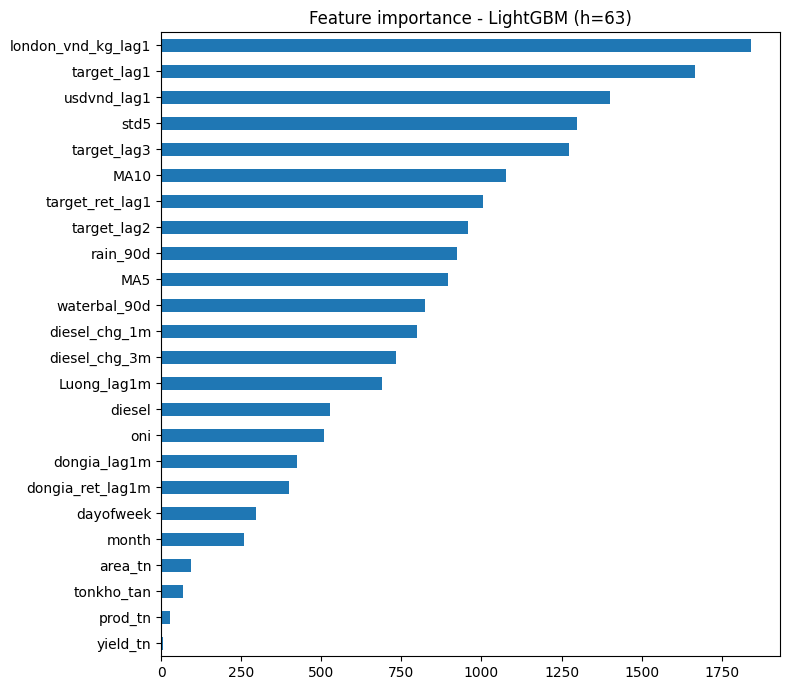

london_vnd_kg_lag1    1840
target_lag1           1666
usdvnd_lag1           1400
std5                  1299
target_lag3           1274
MA10                  1078
target_ret_lag1       1005
target_lag2            958
rain_90d               925
MA5                    895
waterbal_90d           825
diesel_chg_1m          799
diesel_chg_3m          734
Luong_lag1m            689
diesel                 528
oni                    510
dongia_lag1m           425
dongia_ret_lag1m       399
dayofweek              297
month                  260
area_tn                 92
tonkho_tan              69
prod_tn                 27
yield_tn                 6
dtype: int32


In [103]:
# LUU Y: cell nay fit tren TOAN BO du lieu -> chi de XEM do quan trong feature,
# KHONG dung de chon feature (selection bias).
tree_pref = [m for m in ['LightGBM','XGBoost','RandomForest'] if m in MODELS]
imp_name = next((c for c in tree_pref if c in res['Model'].values), 'RandomForest')

yfull = (future - anchor) if TARGET_MODE == 'delta' else future
msk = future.notna()
mdl = MODELS[imp_name]()
mdl.fit(X[msk], yfull[msk])
imp = getattr(mdl, 'feature_importances_', None)
if imp is not None:
    fi = pd.Series(imp, index=FEATURES).sort_values()
    fi.plot(kind='barh', figsize=(8,7), title=f'Feature importance - {imp_name} (h={HORIZON})')
    plt.tight_layout(); plt.savefig(f'feature_importance_h{HORIZON}_{TARGET_MODE}.png', dpi=120); plt.show()
    print(fi.sort_values(ascending=False))
else:
    print('Model', imp_name, 'khong co feature_importances_')


## 12. Kiem dinh Diebold-Mariano (vs Naive)

|DM| > 1.96 => chenh lech sai so co y nghia thong ke 5%.

In [104]:
def diebold_mariano(y, p1, p2, h=1):
    # loss = squared error; DM>0: p1 te hon p2. HAC/Newey-West lag = h-1.
    d = (y - p1) ** 2 - (y - p2) ** 2
    d = d[np.isfinite(d)]
    nn = len(d)
    var = np.var(d, ddof=0)
    for k in range(1, h):
        var += 2 * np.cov(d[k:], d[:-k])[0, 1]
    return float(d.mean() / np.sqrt(var / nn))

bb = results_blocks[best].reindex(EVAL)['pred'].values.astype(float)
pn = results_blocks['Naive'].reindex(EVAL)['pred'].values.astype(float)
msk = np.isfinite(bb) & np.isfinite(pn)
dm = diebold_mariano(y_true[msk], bb[msk], pn[msk], h=HORIZON)
print(f'DM ({best} vs Naive) tai chan troi {HORIZON_NAME} = {round(dm,3)}')
print('  |DM|>1.96 => khac biet co y nghia 5%; DM>0 => Naive tot hon best.')


DM (SVR vs Naive) tai chan troi 1 quy = nan
  |DM|>1.96 => khac biet co y nghia 5%; DM>0 => Naive tot hon best.


C:\Users\quangbeone\AppData\Local\Temp\ipykernel_29632\1157482943.py:9: RuntimeWarning: invalid value encountered in sqrt
  return float(d.mean() / np.sqrt(var / nn))


## 13. Ket luan & buoc tiep

- So sanh **RMSE/MAE/MASE** giua cac model; **MASE < 1** nghia la thang naive.
- **DA(%)** cao = du bao dung huong tot (quan trong cho quyet dinh mua/ban).
- Doi `TARGET_MODE` giua `level` va `delta` de xem anh huong cua viec ngoai suy.
- Buoc tiep: (1) tune hyperparameter (GridSearch theo thoi gian); (2) **ablation** bo bot feature trung (rain_90d vs waterbal_90d, diesel_chg_1m vs 3m, usdvnd vs london_vnd); (3) thu hybrid (tuyen tinh + cay hoc phan du).